# Was 2024 warmer or wetter than normal?

Compare 2024 monthly observations at Will Rogers World Airport in Oklahoma City
with the 1991–2020 normals for the same station. The anomaly is the observed
value minus its normal: a positive temperature anomaly means the month ran
warmer than its 30-year average, and a positive precipitation anomaly means it
was wetter. The answer describes this station and year, not a climate trend or
statistical significance.

This study needs `usdata[pandas]` and matplotlib. It downloads two small CSVs,
under 2 KB together, and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:58:08+00:00
usdata 0.26.0; pandas 3.0.6


## Data

One manifest declares the two sources the comparison needs:

- [Monthly station climate](https://usdata.dev/datasets/noaa/gsom/) (GSOM):
  the observations, the twelve 2024 UTC calendar months of mean temperature
  and total precipitation at station USW00013967.
- [Climate normals](https://usdata.dev/datasets/noaa/climate-normals/): the
  1991–2020 baseline for the same station. The source carries no dates,
  because normals are 30-year averages rather than observations;
  `period: monthly` selects the monthly dataset, and the whole year comes
  back.

`units: metric` asks both services for millimetres and degrees Celsius.

In [2]:
print(manifest.read_text())

name: okc-climate-anomalies
sources:
  - dataset: noaa:gsom
    start: 2024-01-01
    end: 2024-12-31
    variables: [TAVG, PRCP]
    params:
      stations: USW00013967
      units: metric
  - dataset: noaa:climate-normals
    variables: [MLY-TAVG-NORMAL, MLY-PRCP-NORMAL]
    params:
      period: monthly
      stations: USW00013967
      units: metric



## Pull and open both sources

The first pull writes one lockfile, covering both assets, next to the manifest.
Index the fetched items by `dataset_id` rather than by position. The two `DATE`
columns are different labels: GSOM uses `YYYY-MM` and monthly normals use `MM`,
so both are read as text with an explicit `dtype`.

NCEI's `units=metric` converts `MLY-PRCP-NORMAL` but **not** `MLY-TAVG-NORMAL`,
which comes back in degrees Fahrenheit, keeping the leading spaces the service
puts on standard-unit values. That is not the only data type `units=metric`
gets wrong; the [normals guide](https://docs.usdata.dev/providers/noaa-normals/)
lists what was probed, including the derived codes it mis-converts. Read
`MLY-TAVG-NORMAL` as text so the mismatch stays visible instead of quietly
subtracting Fahrenheit from Celsius below.

In [3]:
result = pull(manifest)
items = {item.asset.dataset_id: item for item in result.fetched}
assert len(items) == len(result.fetched) == 2, "expected exactly one asset per source"
observed = items["noaa:gsom"].open_csv(dtype={"DATE": "string"}).set_index("DATE")
normals = (
    items["noaa:climate-normals"]
    .open_csv(dtype={"DATE": "string", "MLY-TAVG-NORMAL": "string"})
    .set_index("DATE")
)
print(f"Observed months: {len(observed)}; monthly normals rows: {len(normals)}")
display(observed[["STATION", "PRCP", "TAVG"]].head(3))
display(normals[["MLY-PRCP-NORMAL", "MLY-TAVG-NORMAL"]].head(3))

Observed months: 12; monthly normals rows: 12


,STATION,PRCP,TAVG
DATE,,,
2024-01,USW00013967,45.7,1.1
2024-02,USW00013967,31.7,9.7
2024-03,USW00013967,42.7,12.7


,MLY-PRCP-NORMAL,MLY-TAVG-NORMAL
DATE,,
01,33.5,38.2
02,36.1,42.3
03,64.8,51.2


In [4]:
for item in result.fetched:
    print(item.asset.dataset_id)
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print("Source:", item.provenance.source_url)
    print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
    print("Checksum:", item.provenance.checksum)
    print()

noaa:gsom
Bytes: 892; cache hit: False
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=global-summary-of-the-month&stations=USW00013967&startDate=2024-01-01&endDate=2024-12-31&format=csv&units=metric&includeStationLocation=1&dataTypes=TAVG%2CPRCP
Retrieved (UTC): 2026-09-24T05:58:08+00:00
Checksum: sha256:9d2617cd3f94200de386b0698c0e01afea7d84466e578c3da05b176b615c7a46

noaa:climate-normals
Bytes: 918; cache hit: False
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=normals-monthly-1991-2020&stations=USW00013967&format=csv&units=metric&includeStationLocation=1&startDate=2020-01-01&endDate=2020-12-31&dataTypes=MLY-TAVG-NORMAL%2CMLY-PRCP-NORMAL
Retrieved (UTC): 2026-09-24T05:58:08+00:00
Checksum: sha256:81fe2b4e9d7368e8e9910b18ea9f69db3b4727df236a62080fcc824fe0858fb4



## Align the months and subtract

Normals are labelled by two-digit month, so select them in the observed order
and relabel them onto the observed `YYYY-MM` index before subtracting; a missing
month raises rather than aligning to nothing. The Fahrenheit normal is
converted only after checking its standard-unit marker and that the result is
plausible against the observations.

One station's year against one 30-year baseline is not a trend, and a different
baseline period would move every number. Precipitation anomalies are totals, so
a single wet month dominates its sign. Missing measurements stay missing.

In [5]:
aligned = normals.loc[observed.index.str.slice(5, 7)].set_axis(observed.index)
fahrenheit = aligned["MLY-TAVG-NORMAL"]
if not fahrenheit.str.startswith(" ").all():
    raise ValueError("MLY-TAVG-NORMAL lost its standard-unit marker; recheck units first")
tavg_normal = (fahrenheit.astype("float64") - 32) * 5 / 9
if (observed["TAVG"] - tavg_normal).abs().max() > 10:
    raise ValueError("converted MLY-TAVG-NORMAL is implausible against observed TAVG")
prcp_normal = aligned["MLY-PRCP-NORMAL"]
frame = pd.DataFrame(
    {
        "TAVG": observed["TAVG"],
        "TAVG normal": tavg_normal,
        "TAVG anomaly": observed["TAVG"] - tavg_normal,
        "PRCP": observed["PRCP"],
        "PRCP normal": prcp_normal,
        "PRCP anomaly": observed["PRCP"] - prcp_normal,
    }
).round(1)
assert frame.notna().all().all(), "every selected month needs an observation and a normal"
frame

,TAVG,TAVG normal,TAVG anomaly,PRCP,PRCP normal,PRCP anomaly
DATE,,,,,,
2024-01,1.1,3.4,-2.3,45.7,33.5,12.2
2024-02,9.7,5.7,4.0,31.7,36.1,-4.4
2024-03,12.7,10.7,2.0,42.7,64.8,-22.1
2024-04,17.3,15.2,2.1,84.7,91.4,-6.7
2024-05,21.7,20.1,1.6,91.8,134.9,-43.1
2024-06,26.7,24.9,1.8,95.2,114.0,-18.8
2024-07,27.4,27.6,-0.2,80.8,91.2,-10.4
2024-08,28.2,27.1,1.1,171.5,91.4,80.1
2024-09,23.8,22.6,1.2,54.1,94.5,-40.4


Each month's departure from its 1991–2020 normal: warmer and drier months in
orange, cooler and wetter months in blue.

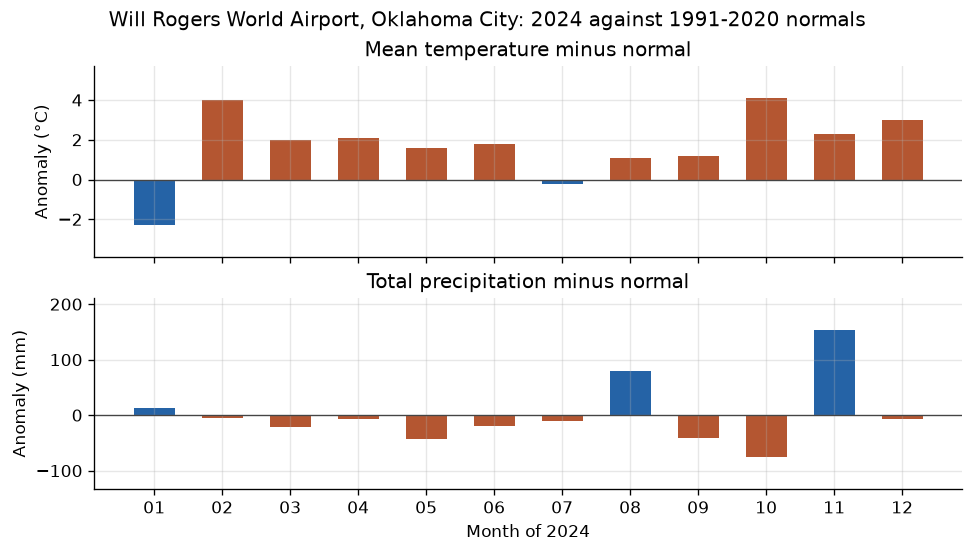

In [6]:
months = frame.index.str.slice(5, 7)
fig, axes = plt.subplots(2, 1, sharex=True, layout="constrained")
for ax, column, title, unit, (above, below) in zip(
    axes,
    ["TAVG anomaly", "PRCP anomaly"],
    ["Mean temperature minus normal", "Total precipitation minus normal"],
    ["Anomaly (°C)", "Anomaly (mm)"],
    [("#b45631", "#2563a6"), ("#2563a6", "#b45631")],
    strict=True,
):
    values = frame[column]
    ax.bar(months, values, width=0.6, color=[above if value >= 0 else below for value in values])
    ax.axhline(0, color="#444444", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.margins(y=0.25)
axes[-1].set_xlabel("Month of 2024")
fig.suptitle("Will Rogers World Airport, Oklahoma City: 2024 against 1991-2020 normals")
plt.show()

## What the comparison shows

Count warmer-than-normal months and compare the twelve-month precipitation
total with the sum of the monthly normals. The summary uses the unrounded
values; the table and plot round to one decimal place. "Normal" here means
the 1991–2020 average at this station, not a threshold for statistical
significance.

In [7]:
temperature_difference = observed["TAVG"] - tavg_normal
precipitation_difference = observed["PRCP"].sum() - prcp_normal.sum()
warmer_months = int((temperature_difference > 0).sum())
wetness = (
    "wetter"
    if precipitation_difference > 0
    else "drier"
    if precipitation_difference < 0
    else "equal to normal"
)
print(f"{warmer_months} of 12 months had a higher mean temperature than normal.")
print(f"2024 precipitation: {observed['PRCP'].sum():.1f} mm; normal: {prcp_normal.sum():.1f} mm.")
print(f"The year was {wetness}: {precipitation_difference:+.1f} mm relative to normal.")
print("Scope: Will Rogers World Airport, 2024, compared with 1991-2020 monthly normals.")

10 of 12 months had a higher mean temperature than normal.
2024 precipitation: 942.4 mm; normal: 924.3 mm.
The year was wetter: +18.1 mm relative to normal.
Scope: Will Rogers World Airport, 2024, compared with 1991-2020 monthly normals.


## Pin and cite

`verify` checks the manifest and cached bytes against the lockfile, offline.
A repeat pull then restores both pinned assets from the lockfile and the
cache. Keep the manifest, lockfile, and cached bytes together; the citations
below are what a methods section needs, and `usdata cite dataset.yaml` prints
the same.

In [8]:
assert verify(manifest) == []
again = pull(manifest)
print(f"Restored from lockfile: {again.from_lockfile}")
print(f"All assets came from cache: {all(item.from_cache for item in again.fetched)}")
print()
for citation in cite_lockfile(manifest):
    print(citation.as_text())

Restored from lockfile: True
All assets came from cache: True

noaa:gsom
  Lawrimore, Jay H.; Ray, Ron; Applequist, Scott; Korzeniewski, Bryant; Menne, Matthew J. (2016): Global Summary of the Month (GSOM), Version 1. NOAA National Centers for Environmental Information. https://doi.org/10.7289/V5QV3JJ5
  homepage: https://www.ncei.noaa.gov/access/search/data-search/global-summary-of-the-month
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00946/html
  retrieved: 2026-09-24; 1 checksummed asset (892 bytes) pinned by usdata 0.26.0
  sources: 1
noaa:climate-normals
  Palecki, Michael; Durre, Imke; Applequist, Scott; Arguez, Anthony; Lawrimore, Jay (2021). U.S. Climate Normals 2020 (1991-2020). NOAA National Centers for Environmental Information; cite the record for the period used
  homepage: https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals
  license: US Government Work (public d

## What was awkward

- `units: metric` is not honoured for every normals code: `MLY-TAVG-NORMAL`
  arrives in degrees Fahrenheit beside a converted `MLY-PRCP-NORMAL`, and the
  only marker is a leading space on the value. Nothing in the asset or its
  provenance says so; the notebook reads the column as text and checks.
- The two sources label months differently (`YYYY-MM` against `MM`), so the
  join is a string slice and a relabel rather than a merge on a shared key.
- Neither source is a stable file. Both are query-shaped URLs that the
  agencies revise: NCEI revises GSOM as late station reports arrive, and the
  1991–2020 normals are corrected occasionally even though their period is
  fixed. Restoration then exits 4, reports every asset whose bytes changed,
  and rewrites nothing; accepting new bytes is a deliberate
  `usdata pull dataset.yaml --update noaa:gsom` (see
  [`--update`](https://docs.usdata.dev/reference/manifests/#pull-refresh-and-restore)).
  A checksum detects a revision but cannot recreate bytes upstream no longer
  serves.